# Empirical Auditability Evaluation

Runs the three audit tests on the empirical (FRED-based) pipeline outputs.

Reads the prediction CSVs saved by 02_pto, 03_bb and 04_dfl and 
stability outputs to run calibration, discriminatory power and stability tests.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from minou_colours import MINOU_COLOURS

RESULTS_ROOT = Path("../results")

LGD = 0.45
# significance level for the calibration test          
SIG_LEVEL = 0.05      
# Newey-West HAC lag count for the calibration test
NW_LAGS = 4            
# MLP training seeds saved for the D_seed stability check
SEED_ENSEMBLE = (42, 43, 44, 45, 46)   


## Helper functions

- `mean_bias_test` — two-sided HAC (Newey-West) test of $H_0: \mathbb{E}[e_t]=0$.
- `nber_stress_dummy` — binary stress indicator: NBER recession quarters plus a 150%
  post-recession extension.

In [2]:
def mean_bias_test(pd_hat, target, nw_lags=NW_LAGS):
    """Two-sided HAC test of H0: E[pd_hat - target] = 0 (z = bias / SE_HAC)."""
    d = np.asarray(pd_hat, dtype=float) - np.asarray(target, dtype=float)
    n = len(d)
    bias = float(np.mean(d))

    def newey_west_lrv(d, lags):
        d = d - d.mean()
        v = float(np.mean(d * d))
        for k in range(1, min(lags, n - 1) + 1):
            w = 1.0 - k / (lags + 1.0)
            v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
        return v / n

    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return dict(bias=bias,
                    hac_se=float("nan"), z_stat=float("nan"), p_value=float("nan"), n=n)
    hac_se = float(np.sqrt(lrv))
    z_stat = bias / hac_se
    p_value = 2.0 * norm.sf(abs(z_stat))
    return dict(bias=bias,
                hac_se=hac_se, z_stat=float(z_stat), p_value=float(p_value), n=n)


# NBER recession dates plus a 150% post-recession extension
REGIME_EXTENSION_FRACTION = 1.50
NBER_RECESSION_QUARTERS = pd.PeriodIndex([
    "1990Q3", "1990Q4", "1991Q1",
    "2001Q1", "2001Q2", "2001Q3", "2001Q4",
    "2007Q4", "2008Q1", "2008Q2", "2008Q3", "2008Q4", "2009Q1", "2009Q2",
    "2020Q1", "2020Q2",
], freq="Q")


def _extend_nber_recession_quarters(recession_quarters, fraction):
    recession_quarters = pd.PeriodIndex(recession_quarters, freq="Q").sort_values()
    extended = set(recession_quarters.astype(str))
    starts = recession_quarters[~(recession_quarters - 1).isin(set(recession_quarters))]
    ends = recession_quarters[~(recession_quarters + 1).isin(set(recession_quarters))]
    for start, end in zip(starts, ends):
        duration_q = (end.year - start.year) * 4 + end.quarter - start.quarter + 1
        extension_q = int(np.ceil(duration_q * fraction))
        extended.update(str(end + i) for i in range(1, extension_q + 1))
    return pd.PeriodIndex(sorted(extended), freq="Q")


NBER_STRESS_QUARTERS = _extend_nber_recession_quarters(NBER_RECESSION_QUARTERS, REGIME_EXTENSION_FRACTION)

def nber_stress_dummy(dates):
    periods = pd.PeriodIndex(pd.to_datetime(dates), freq="Q")
    return periods.isin(NBER_STRESS_QUARTERS).astype(int)

## Load and reshape data

In [3]:
def load_wide(source):
    path = RESULTS_ROOT / source / f"{source}_quarterly_pd_irb_predictions.csv"
    return pd.read_csv(path, parse_dates=["date"])

BASE_COLS = ["date", "c_q_realised", "pd_q_realised", "alpha_oracle"]

def wide_to_long(wide, models):
    records = []
    for m in models:
        sub = wide[BASE_COLS].copy()
        sub["model"] = m
        sub["pd_q_hat"] = wide[f"pd_q_hat_{m}"] if f"pd_q_hat_{m}" in wide.columns else np.nan
        sub["alpha_hat"] = wide[f"alpha_hat_{m}"] if f"alpha_hat_{m}" in wide.columns else np.nan
        records.append(sub)
    return pd.concat(records, ignore_index=True)

pto_wide = load_wide("pto")
bb_wide = load_wide("blackbox")
dfl_wide = load_wide("dfl")

long_pto = wide_to_long(pto_wide, ["linear", "mlp", "persistence"])
long_bb = wide_to_long(bb_wide, ["blackbox_linear", "blackbox_mlp"])
long_dfl = wide_to_long(dfl_wide, ["dfl_linear", "dfl_mlp"])

audit_long = pd.concat([long_pto, long_bb, long_dfl], ignore_index=True)
audit_long["stress"] = nber_stress_dummy(audit_long["date"])

PD_MODELS = ["linear", "mlp", "persistence", "dfl_linear", "dfl_mlp"]
BLACKBOX_MODELS = ["blackbox_linear", "blackbox_mlp"]
ALL_MODELS = PD_MODELS + BLACKBOX_MODELS

print(f"Audit panel rows: {len(audit_long)} across models {sorted(audit_long['model'].unique())}")
display(audit_long.groupby("model").size().rename("n_obs").to_frame())

Audit panel rows: 567 across models ['blackbox_linear', 'blackbox_mlp', 'dfl_linear', 'dfl_mlp', 'linear', 'mlp', 'persistence']


,n_obs
model,
blackbox_linear,81
blackbox_mlp,81
dfl_linear,81
dfl_mlp,81
linear,81
mlp,81
persistence,81


## Test 1 — Calibration (mean-bias test)

$H_0: \mathbb{E}[e_t] = 0$ where $e_t = \widehat{PD}_t - L_t$ and $L_t = c_t^{realised}/LGD$,
tested with Newey-West HAC standard errors (4 quarterly lags). **Statistically significant calibration bias** is flagged when the null is
rejected at the 5% level.

In [4]:
calibration_rows = []
for model_name in PD_MODELS:
    g = audit_long[audit_long["model"] == model_name].sort_values("date")
    res = mean_bias_test(g["pd_q_hat"], g["pd_q_realised"])
    calibration_rows.append({
        "model": model_name, "n": res["n"], "bias": res["bias"], "bias_bp": res["bias"] * 1e4,
        "hac_se": res["hac_se"], "z_stat": res["z_stat"], "p_value": res["p_value"],
        "result": "FAIL (significant bias)" if res["p_value"] < SIG_LEVEL else "PASS (no significant bias)",
    })
calibration_table = pd.DataFrame(calibration_rows).set_index("model").loc[PD_MODELS]
display(calibration_table)

,n,bias,bias_bp,hac_se,z_stat,p_value,result
model,,,,,,,
linear,81,0.001949,19.487900,0.000967,2.015865,4.381406e-02,FAIL (significant bias)
mlp,81,0.000603,6.034036,0.000211,2.861932,4.210668e-03,FAIL (significant bias)
persistence,81,-0.000019,-0.192044,0.000144,-0.133654,8.936763e-01,PASS (no significant bias)
dfl_linear,81,0.004463,44.626347,0.002092,2.132945,3.292926e-02,FAIL (significant bias)
dfl_mlp,81,0.002482,24.820708,0.000470,5.279165,1.297737e-07,FAIL (significant bias)


## Test 2 — Discriminatory power (AUROC vs. stress quarter)

AUROC of $\widehat{PD}_t$ against the 150%-extended-NBER stress dummy: the probability that a
randomly selected stress quarter receives a higher predicted PD than a randomly selected normal
quarter. Bands follow Wu (2021): **>0.7 strong, 0.6–0.7 some, 0.5–0.6 weak, ≤0.5 none**.

In [5]:
def auroc_band(auc):
    if auc > 0.7:
        return "strong"
    if auc > 0.6:
        return "some"
    if auc > 0.5:
        return "weak"
    return "none"


discrimination_rows = []
for model_name in PD_MODELS:
    g = audit_long[audit_long["model"] == model_name].sort_values("date")
    auc = float(roc_auc_score(g["stress"].to_numpy(), g["pd_q_hat"].to_numpy()))
    discrimination_rows.append({
        "model": model_name, "n": len(g), "n_stress_quarters": int(g["stress"].sum()),
        "auroc": auc, "band": auroc_band(auc),
    })
discrimination_table = pd.DataFrame(discrimination_rows).set_index("model").loc[PD_MODELS]
display(discrimination_table)

,n,n_stress_quarters,auroc,band
model,,,,
linear,81,23,0.921289,strong
mlp,81,23,0.900300,strong
persistence,81,23,0.954648,strong
dfl_linear,81,23,0.904048,strong
dfl_mlp,81,23,0.916792,strong


## Combined summary - Calibration and Discriminatory Power

In [6]:
def _finite(table, model, column):
    value = table.loc[model, column] if model in table.index and column in table else np.nan
    return float(value) if pd.notna(value) and np.isfinite(value) else np.nan

summary = pd.DataFrame(index=ALL_MODELS)
summary.index.name = "model"
summary["calibration_bias_bp"] = [_finite(calibration_table, m, "bias_bp") for m in ALL_MODELS]
summary["calibration_result"] = [calibration_table.loc[m, "result"] if m in calibration_table.index else "N/A" for m in ALL_MODELS]
summary["auroc"] = [_finite(discrimination_table, m, "auroc") for m in ALL_MODELS]
summary["discrimination_band"] = [discrimination_table.loc[m, "band"] if m in discrimination_table.index else "N/A" for m in ALL_MODELS]
display(summary)

latex_order = [("PTO", "Linear", "linear"), ("PTO", "MLP", "mlp"),
               ("DFL", "Linear", "dfl_linear"), ("DFL", "MLP", "dfl_mlp"),
               ("Black Box", "Linear", "blackbox_linear"), ("Black Box", "MLP", "blackbox_mlp"),
               ("Persistence", "Persistence", "persistence")]

def _latex_p(model):
    if model not in calibration_table.index: return "N/A"
    p = calibration_table.loc[model, "p_value"]
    if not np.isfinite(p): return "N/A"
    value = "<0.001" if p < 0.001 else f"{p:.2f}"
    return f"\\textbf{{{value}}}" if p < SIG_LEVEL else value

def _latex_num(value, decimals=2):
    return "N/A" if pd.isna(value) else f"{float(value):.{decimals}f}"

latex_lines = [r"\begin{table}[htbp]", r"\centering", r"\scriptsize",
               r"\caption{Empirical auditability diagnostics across model specifications.}",
               r"\label{tab:empirical_audit_results}", r"\resizebox{\textwidth}{!}{%",
               r"\begin{tabular}{@{}llrrr@{}}", r"\toprule",
               r"Group & Model & Mean bias (bp) & HAC p-value & AUROC \\", r"\midrule"]
for group, label, model in latex_order:
    group_cell = (f"\\multirow{{2}}{{*}}{{{group}}}" if label == "Linear" and group != "Persistence" else group if group == "Persistence" else "")
    bias = _latex_num(summary.loc[model, "calibration_bias_bp"])
    auroc = _latex_num(summary.loc[model, "auroc"])
    latex_lines.append(f"{group_cell} & {label} & {bias} & {_latex_p(model)} & {auroc} " + chr(92) * 2)
    if label == "MLP" and group != "Persistence": latex_lines.append(r"\midrule")
latex_lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
print("\n".join(latex_lines))

,calibration_bias_bp,calibration_result,auroc,discrimination_band
model,,,,
linear,19.487900,FAIL (significant bias),0.921289,strong
mlp,6.034036,FAIL (significant bias),0.900300,strong
persistence,-0.192044,PASS (no significant bias),0.954648,strong
dfl_linear,44.626347,FAIL (significant bias),0.904048,strong
dfl_mlp,24.820708,FAIL (significant bias),0.916792,strong
blackbox_linear,NaN,N/A,NaN,N/A
blackbox_mlp,NaN,N/A,NaN,N/A


\begin{table}[htbp]
\centering
\scriptsize
\caption{Empirical auditability diagnostics across model specifications.}
\label{tab:empirical_audit_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{@{}llrrr@{}}
\toprule
Group & Model & Mean bias (bp) & HAC p-value & AUROC \\
\midrule
\multirow{2}{*}{PTO} & Linear & 19.49 & \textbf{0.04} & 0.92 \\
 & MLP & 6.03 & \textbf{0.00} & 0.90 \\
\midrule
\multirow{2}{*}{DFL} & Linear & 44.63 & \textbf{0.03} & 0.90 \\
 & MLP & 24.82 & \textbf{<0.001} & 0.92 \\
\midrule
\multirow{2}{*}{Black Box} & Linear & N/A & N/A & N/A \\
 & MLP & N/A & N/A & N/A \\
\midrule
Persistence & Persistence & -0.19 & 0.89 & 0.95 \\
\bottomrule
\end{tabular}}
\end{table}


## Test 3 — Stability
$D_{refit}$ in prediction space, reported against both **full-sample** reference and a
**successive**-refit reference. Measured against $RMSE$ and against $D_{seed}$.

In [7]:
def load_reference_predictions(source, kind):
    """Per-refit predictions at a fixed reference input set."""
    path = RESULTS_ROOT / source / f"{source}_stability_{kind}_reference_outputs.csv"
    return pd.read_csv(path)


def _sort_by_refit(df):
    sort_col = "test_date" if "test_date" in df.columns else "refit_step"
    return df.sort_values(sort_col).reset_index(drop=True)


def _reference_row_mask(df):
    """Full-sample reference row: explicitly labelled if present, else the chronologically
    last (most training data) refit."""
    if "refit_step" in df.columns:
        mask = df["refit_step"].astype(str).str.lower().isin(["full", "full_sample", "-1"])
        if mask.any():
            return mask
    mask = pd.Series(False, index=df.index)
    mask.iloc[-1] = True
    return mask


def dispersion_full_sample(df, metric):
    """D_refit against the full-sample reference row."""
    cols = [c for c in df.columns if re.match(rf"^ref\d+_{re.escape(metric)}_mean$", c)]
    if not cols or len(df) < 2:
        return np.nan, 0
    df = _sort_by_refit(df)
    ref_mask = _reference_row_mask(df)
    reference = df.loc[ref_mask, cols].iloc[0].to_numpy(dtype=float)
    refits = df.loc[~ref_mask, cols].to_numpy(dtype=float)
    if len(refits) == 0:
        return np.nan, 0
    return float(np.sqrt(np.mean((refits - reference) ** 2))), len(refits)


def dispersion_successive(df, metric):
    """D_refit between each pair of successive refits, pooled."""
    cols = [c for c in df.columns if re.match(rf"^ref\d+_{re.escape(metric)}_mean$", c)]
    if not cols:
        return np.nan, 0
    df = _sort_by_refit(df)
    values = df.loc[~_reference_row_mask(df), cols].to_numpy(dtype=float)
    if len(values) < 2:
        return np.nan, 0
    adjacent = values[1:] - values[:-1]
    return float(np.sqrt(np.mean(adjacent ** 2))), len(values) - 1


def dispersion_seed(df, metric, seeds=SEED_ENSEMBLE):
    """D_seed: dispersion across MLP training seeds at the latest refit, same reference inputs."""
    seed_cols = [c for c in df.columns if c.startswith("ref") and f"_{metric}_seed" in c]
    if not seed_cols:
        return np.nan
    latest = _sort_by_refit(df).iloc[-1]
    point_ids = sorted({c.split("_")[0][3:] for c in seed_cols})
    sq_devs = []
    for j in point_ids:
        cols = [f"ref{j}_{metric}_seed{int(s)}" for s in seeds]
        if all(c in df.columns for c in cols):
            v = latest[cols].to_numpy(dtype=float)
            sq_devs.append((v - v.mean()) ** 2)
    return float(np.sqrt(np.mean(np.concatenate(sq_devs)))) if sq_devs else np.nan

In [8]:
STABILITY_MODELS = [
    ("linear", "pto", "linear"), ("mlp", "pto", "mlp"),
    ("dfl_linear", "dfl", "linear"), ("dfl_mlp", "dfl", "mlp"),
    ("blackbox_linear", "blackbox", "linear"), ("blackbox_mlp", "blackbox", "mlp"),
]

stability_rows = []
for model_name, source, kind in STABILITY_MODELS:
    g = audit_long[audit_long["model"] == model_name].sort_values("date")
    df = load_reference_predictions(source, kind)
    row = {"model": model_name}
    if model_name in PD_MODELS:
        rmse_pd = float(np.sqrt(np.mean((g["pd_q_hat"] - g["pd_q_realised"]) ** 2)))
        d_pd_full, n_full = dispersion_full_sample(df, "pd_q_hat")
        d_pd_succ, _ = dispersion_successive(df, "pd_q_hat")
        d_pd_seed = dispersion_seed(df, "pd_q_hat")
        row.update({
            "RMSE_PD": rmse_pd, "D_PD_full": d_pd_full, "n_refits_PD": n_full,
            "D_PD_successive": d_pd_succ, "D_seed_PD": d_pd_seed,
            "D_PD_full_over_RMSE": d_pd_full / rmse_pd if rmse_pd else np.nan,
            "D_PD_full_over_D_seed": d_pd_full / d_pd_seed if d_pd_seed else np.nan,
            "D_PD_successive_over_RMSE": d_pd_succ / rmse_pd if rmse_pd else np.nan,
            "D_PD_successive_over_D_seed": d_pd_succ / d_pd_seed if d_pd_seed else np.nan,
        })
    else:
        row.update({k: np.nan for k in ["RMSE_PD", "D_PD_full", "D_PD_successive", "D_seed_PD",
                                          "D_PD_full_over_RMSE", "D_PD_full_over_D_seed",
                                          "D_PD_successive_over_RMSE", "D_PD_successive_over_D_seed"]})
        row["n_refits_PD"] = 0

    rmse_alpha = float(np.sqrt(np.mean((g["alpha_hat"] - g["alpha_oracle"]) ** 2)))
    d_alpha_full, n_full_a = dispersion_full_sample(df, "alpha_hat")
    d_alpha_succ, _ = dispersion_successive(df, "alpha_hat")
    d_alpha_seed = dispersion_seed(df, "alpha_hat")
    row.update({
        "RMSE_alpha": rmse_alpha, "D_alpha_full": d_alpha_full, "n_refits_alpha": n_full_a,
        "D_alpha_successive": d_alpha_succ, "D_seed_alpha": d_alpha_seed,
        "D_alpha_full_over_RMSE": d_alpha_full / rmse_alpha if rmse_alpha else np.nan,
        "D_alpha_full_over_D_seed": d_alpha_full / d_alpha_seed if d_alpha_seed else np.nan,
        "D_alpha_successive_over_RMSE": d_alpha_succ / rmse_alpha if rmse_alpha else np.nan,
        "D_alpha_successive_over_D_seed": d_alpha_succ / d_alpha_seed if d_alpha_seed else np.nan,
    })
    stability_rows.append(row)

stability_table = pd.DataFrame(stability_rows).set_index("model")
display(stability_table)

,RMSE_PD,D_PD_full,n_refits_PD,D_PD_successive,D_seed_PD,D_PD_full_over_RMSE,D_PD_full_over_D_seed,D_PD_successive_over_RMSE,D_PD_successive_over_D_seed,RMSE_alpha,D_alpha_full,n_refits_alpha,D_alpha_successive,D_seed_alpha,D_alpha_full_over_RMSE,D_alpha_full_over_D_seed,D_alpha_successive_over_RMSE,D_alpha_successive_over_D_seed
model,,,,,,,,,,,,,,,,,,
linear,0.006333,0.007446,80,0.002839,NaN,1.175830,NaN,0.448269,NaN,0.074303,0.043085,80,0.017603,NaN,0.579862,NaN,0.236915,NaN
mlp,0.001388,0.001484,80,0.000337,0.001012,1.068769,1.465554,0.242632,0.332710,0.051677,0.027243,80,0.006542,0.020715,0.527184,1.315154,0.126600,0.315827
dfl_linear,0.013647,0.010659,80,0.003857,NaN,0.781067,NaN,0.282605,NaN,0.137760,0.041890,80,0.024528,NaN,0.304078,NaN,0.178050,NaN
dfl_mlp,0.004038,0.002263,80,0.000865,0.003506,0.560346,0.645449,0.214273,0.246816,0.100664,0.030862,80,0.019978,0.043459,0.306588,0.710145,0.198459,0.459688
blackbox_linear,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.072206,0.042911,80,0.021385,NaN,0.594283,NaN,0.296161,NaN
blackbox_mlp,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.085931,0.035728,80,0.010311,0.022387,0.415775,1.595931,0.119990,0.460577


## Figures

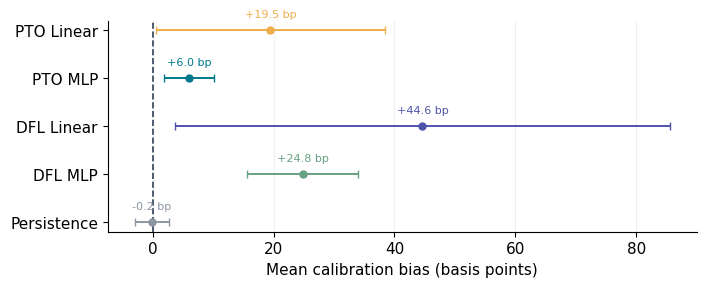

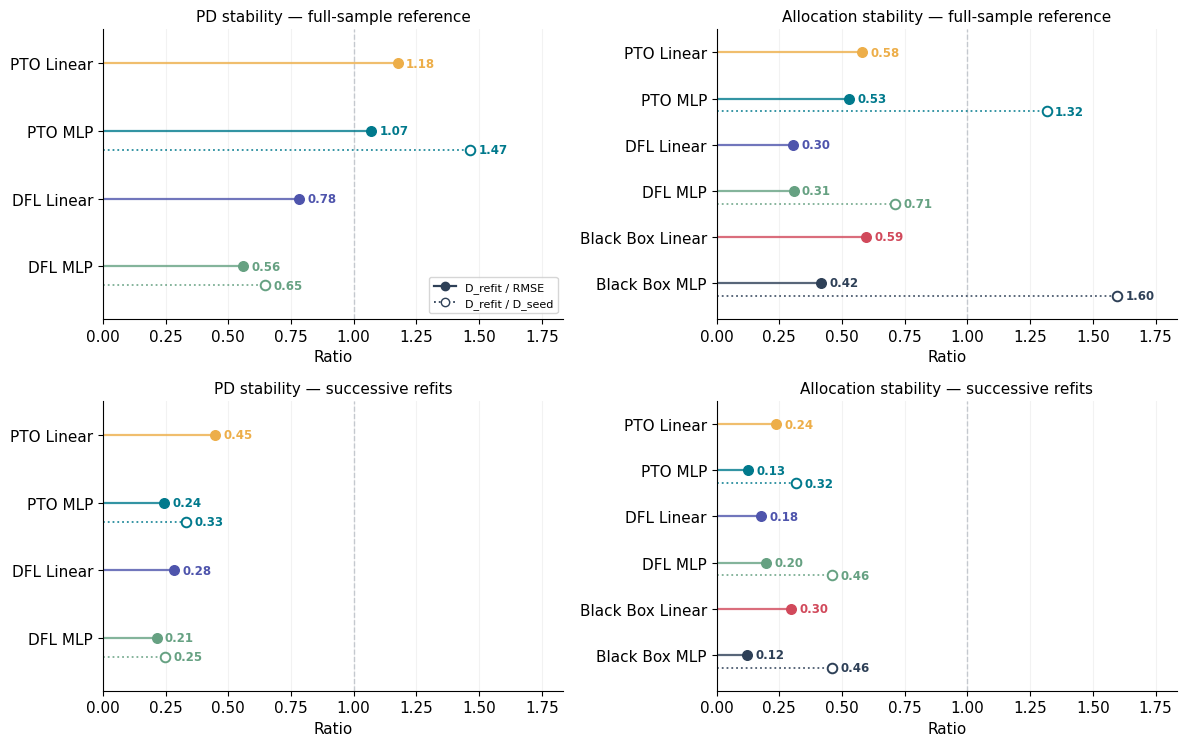

In [10]:
FIGURES_DIR = Path("../figures/06_audit")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

DISPLAY_NAMES = {"linear": "PTO Linear", "mlp": "PTO MLP", "dfl_linear": "DFL Linear", "dfl_mlp": "DFL MLP",
                  "blackbox_linear": "Black Box Linear", "blackbox_mlp": "Black Box MLP", "persistence": "Persistence"}
COLORS = {"linear": MINOU_COLOURS["gold"], "mlp": MINOU_COLOURS["teal"], "dfl_linear": MINOU_COLOURS["purple"],
          "dfl_mlp": MINOU_COLOURS["sage"], "blackbox_linear": MINOU_COLOURS["coral"], "blackbox_mlp": MINOU_COLOURS["navy"],
          "persistence": MINOU_COLOURS["grey"]}

# Calibration bias with 95% HAC confidence intervals.
cal_models = [m for m in ["linear", "mlp", "dfl_linear", "dfl_mlp", "persistence"] if m in calibration_table.index]
cal = calibration_table.loc[cal_models]
y = np.arange(len(cal))
fig, ax = plt.subplots(figsize=(7.2, 3.0))
for yi, model in zip(y, cal_models):
    bi = float(cal.loc[model, "bias_bp"]); ci = 1.96 * float(cal.loc[model, "hac_se"]) * 1e4
    ax.errorbar(bi, yi, xerr=ci, fmt="o", ms=5, color=COLORS[model], ecolor=COLORS[model], capsize=3, lw=1.4)
    ax.annotate(f"{bi:+.1f} bp", (bi, yi), xytext=(0, 8), textcoords="offset points",
                fontsize=8, color=COLORS[model], ha="center", va="bottom")
ax.axvline(0, color=MINOU_COLOURS["navy"], lw=1.2, ls="--")
ax.set_yticks(y, [DISPLAY_NAMES[m] for m in cal_models])
ax.set_xlabel("Mean calibration bias (basis points)")
ax.grid(axis="x", alpha=.18); ax.set_axisbelow(True); ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_calibration_bias.png", dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)

pd_models = [m for m in ["linear", "mlp", "dfl_linear", "dfl_mlp"] if m in stability_table.index]
alpha_models = [m for m in ["linear", "mlp", "dfl_linear", "dfl_mlp", "blackbox_linear", "blackbox_mlp"] if m in stability_table.index]

# Stability figures showing PD and allocation stability for both successive and final fit estimation
def _stability_lollipop(ax, models, col, title, xmax, seed_col=None):
    y = np.arange(len(models))
    vals = stability_table.loc[models, col].to_numpy(dtype=float)
    for yi, model, v in zip(y, models, vals):
        if np.isfinite(v):
            ax.hlines(yi, 0, v, color=COLORS[model], lw=1.6, alpha=.8, zorder=2)
            ax.scatter(v, yi, s=48, color=COLORS[model], zorder=3)
            ax.annotate(f"{v:.2f}", (v, yi), xytext=(6, 0), textcoords="offset points",
                        va="center", fontsize=8.5, fontweight="bold", color=COLORS[model])
        if seed_col is not None and model in stability_table.index:
            seed_v = float(stability_table.loc[model, seed_col])
            if np.isfinite(seed_v):
                seed_y = yi + 0.28
                ax.hlines(seed_y, 0, seed_v, color=COLORS[model], lw=1.3, ls=":", alpha=.85, zorder=2)
                ax.scatter(seed_v, seed_y, s=48, facecolors="white", edgecolors=COLORS[model], linewidths=1.4, zorder=4)
                ax.annotate(f"{seed_v:.2f}", (seed_v, seed_y), xytext=(6, 0), textcoords="offset points",
                            va="center", fontsize=8.5, fontweight="bold", color=COLORS[model])
    ax.axvline(1, color=MINOU_COLOURS["grey"], ls="--", lw=1, alpha=.45, zorder=1)
    ax.set_yticks(y, [DISPLAY_NAMES[m] for m in models]); ax.set_ylim(-0.5, len(models) - 0.22); ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    ax.set_title(title, fontsize=11); ax.set_xlabel("Ratio", fontsize=11)
    ax.grid(axis="x", alpha=.16); ax.set_axisbelow(True)


def _shared_xmax(cols):
    vals = stability_table[cols].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    return max(1.3, float(vals.max()) * 1.15) if vals.size else 1.5


RMSE_COLS = ["D_PD_full_over_RMSE", "D_PD_successive_over_RMSE",
             "D_alpha_full_over_RMSE", "D_alpha_successive_over_RMSE"]
SEED_RATIO_COLS = ["D_PD_full_over_D_seed", "D_PD_successive_over_D_seed",
                   "D_alpha_full_over_D_seed", "D_alpha_successive_over_D_seed"]
RMSE_XMAX = max(_shared_xmax(RMSE_COLS), _shared_xmax(SEED_RATIO_COLS))

fig, axes = plt.subplots(2, 2, figsize=(12, 7.6))
_stability_lollipop(axes[0, 0], pd_models, "D_PD_full_over_RMSE", "PD stability — full-sample reference", RMSE_XMAX, "D_PD_full_over_D_seed")
_stability_lollipop(axes[0, 1], alpha_models, "D_alpha_full_over_RMSE", "Allocation stability — full-sample reference", RMSE_XMAX, "D_alpha_full_over_D_seed")
_stability_lollipop(axes[1, 0], pd_models, "D_PD_successive_over_RMSE", "PD stability — successive refits", RMSE_XMAX, "D_PD_successive_over_D_seed")
_stability_lollipop(axes[1, 1], alpha_models, "D_alpha_successive_over_RMSE", "Allocation stability — successive refits", RMSE_XMAX, "D_alpha_successive_over_D_seed")
axes[0, 0].plot([], [], color=MINOU_COLOURS["navy"], lw=1.6, marker="o", label="D_refit / RMSE")
axes[0, 0].plot([], [], color=MINOU_COLOURS["navy"], lw=1.3, ls=":", marker="o", markerfacecolor="white", label="D_refit / D_seed")
axes[0, 0].legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_stability_ratios.png", dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)